In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

print("Everything is ready!")

Everything is ready!


In [ ]:
# Step 2: Create IoT sensor data

import pandas as pd
import numpy as np

# Make the results repeatable
np.random.seed(42)

# Create 10,000 hourly timestamps
timestamps = pd.date_range(
    start="2025-01-01",
    periods=10000,
    freq="h"
)

# Create normal sensor readings
temperature = np.random.normal(70, 5, 10000)
vibration = np.random.normal(2.5, 0.4, 10000)
voltage = np.random.normal(220, 5, 10000)

# Create failure column
failure = np.zeros(10000, dtype=int)

# Add some machine failures
failure_hours = np.random.choice(
    np.arange(500, 10000),
    size=100,
    replace=False
)

failure[failure_hours] = 1

# Create the DataFrame
df = pd.DataFrame({
    "Timestamp": timestamps,
    "Sensor Temp C": temperature,
    "Sensor Vibration mm": vibration,
    "Sensor Voltage V": voltage,
    "Catastrophic Failure": failure
})

# Display the first 5 rows
df.head()

,Timestamp,Sensor Temp C,Sensor Vibration mm,Sensor Voltage V,Catastrophic Failure
0,2025-01-01 00:00:00,72.483571,2.228602,221.741431,0
1,2025-01-01 01:00:00,69.308678,2.377800,221.416618,0
2,2025-01-01 02:00:00,73.238443,2.261048,215.317401,0
3,2025-01-01 03:00:00,77.615149,2.544167,222.897921,0
4,2025-01-01 04:00:00,68.829233,2.978871,212.549587,0


In [ ]:
# Step 3: Check our dataset

print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

df.info()

Number of rows: 10000
Number of columns: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Timestamp             10000 non-null  datetime64[ns]
 1   Sensor Temp C         10000 non-null  float64       
 2   Sensor Vibration mm   10000 non-null  float64       
 3   Sensor Voltage V      10000 non-null  float64       
 4   Catastrophic Failure  10000 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1)
memory usage: 390.8 KB


In [ ]:
# Step 4: Make sensor readings change before failures

import numpy as np
import pandas as pd

np.random.seed(42)

# Create 10,000 hourly timestamps
timestamps = pd.date_range(
    start="2025-01-01",
    periods=10000,
    freq="h"
)

# Normal machine readings
temperature = np.random.normal(70, 4, 10000)
vibration = np.random.normal(2.5, 0.3, 10000)
voltage = np.random.normal(220, 4, 10000)

# Failure column
failure = np.zeros(10000, dtype=int)

# Choose failure times
failure_times = np.arange(500, 10000, 150)

# Add abnormal sensor behaviour before each failure
for f in failure_times:

    # The 48 hours before failure
    start = f - 48

    for i in range(start, f):

        progress = (i - start) / 48

        # Temperature gradually increases
        temperature[i] += progress * 18

        # Vibration gradually increases
        vibration[i] += progress * 1.5

        # Voltage gradually decreases
        voltage[i] -= progress * 12

    # Very abnormal reading at failure
    temperature[f] += 20
    vibration[f] += 2
    voltage[f] -= 15

    # Mark failure
    failure[f] = 1

# Create the final DataFrame
df = pd.DataFrame({
    "Timestamp": timestamps,
    "Sensor Temp C": temperature,
    "Sensor Vibration mm": vibration,
    "Sensor Voltage V": voltage,
    "Catastrophic Failure": failure
})

# Show first 5 rows
df.head()

,Timestamp,Sensor Temp C,Sensor Vibration mm,Sensor Voltage V,Catastrophic Failure
0,2025-01-01 00:00:00,71.986857,2.296452,221.393145,0
1,2025-01-01 01:00:00,69.446943,2.408350,221.133294,0
2,2025-01-01 02:00:00,72.590754,2.320786,216.253921,0
3,2025-01-01 03:00:00,76.092119,2.533125,222.318337,0
4,2025-01-01 04:00:00,69.063387,2.859154,214.039669,0


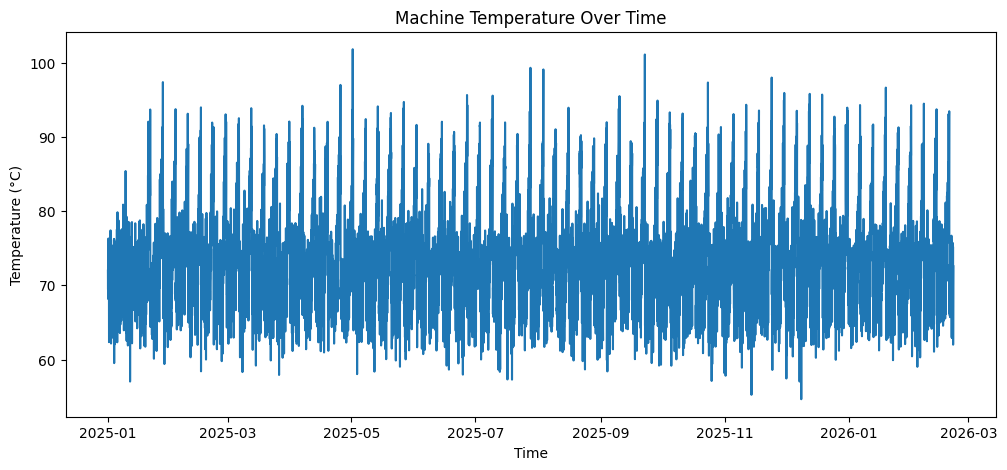

In [ ]:
# Step 5: Visualize temperature

plt.figure(figsize=(12, 5))

plt.plot(df["Timestamp"], df["Sensor Temp C"])

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title("Machine Temperature Over Time")

plt.show()

In [ ]:
# Step 6: Create 12-hour rolling features

# Make sure data is sorted by time
df = df.sort_values("Timestamp")

# 12-hour rolling mean of temperature
df["Temp_Rolling_Mean_12h"] = (
    df["Sensor Temp C"]
    .rolling(window=12)
    .mean()
)

# 12-hour rolling standard deviation of vibration
df["Vibration_Rolling_Std_12h"] = (
    df["Sensor Vibration mm"]
    .rolling(window=12)
    .std()

)

# Display the first 15 rows
df.head(15)

,Timestamp,Sensor Temp C,Sensor Vibration mm,Sensor Voltage V,Catastrophic Failure,Temp_Rolling_Mean_12h,Vibration_Rolling_Std_12h
0,2025-01-01 00:00:00,71.986857,2.296452,221.393145,0,NaN,NaN
1,2025-01-01 01:00:00,69.446943,2.408350,221.133294,0,NaN,NaN
2,2025-01-01 02:00:00,72.590754,2.320786,216.253921,0,NaN,NaN
3,2025-01-01 03:00:00,76.092119,2.533125,222.318337,0,NaN,NaN
4,2025-01-01 04:00:00,69.063387,2.859154,214.039669,0,NaN,NaN
5,2025-01-01 05:00:00,69.063452,2.268687,217.383263,0,NaN,NaN
6,2025-01-01 06:00:00,76.316851,2.800246,212.003649,0,NaN,NaN
7,2025-01-01 07:00:00,73.069739,2.265498,226.234506,0,NaN,NaN
8,2025-01-01 08:00:00,68.122102,2.245712,219.073802,0,NaN,NaN
9,2025-01-01 09:00:00,72.170240,2.745578,228.667536,0,NaN,NaN


In [ ]:
# Step 7: Remove rows with missing rolling values

df = df.dropna().reset_index(drop=True)

print("Rows after removing NaN:", len(df))

df.head()

Rows after removing NaN: 9989


,Timestamp,Sensor Temp C,Sensor Vibration mm,Sensor Voltage V,Catastrophic Failure,Temp_Rolling_Mean_12h,Vibration_Rolling_Std_12h
0,2025-01-01 11:00:00,68.137081,2.755423,221.792393,0,71.183821,0.246993
1,2025-01-01 12:00:00,70.967849,2.105261,217.655089,0,71.098904,0.268190
2,2025-01-01 13:00:00,62.346879,2.360215,215.814600,0,70.507232,0.270153
3,2025-01-01 14:00:00,63.100329,2.746897,222.091886,0,69.716363,0.272020
4,2025-01-01 15:00:00,67.750850,2.512463,219.713944,0,69.021257,0.272123


In [ ]:
# Step 8: Create the 24-hour prediction target

df["Failure_In_24_Hours"] = (
    df["Catastrophic Failure"].shift(-24)
)

# Look at the last few rows
df[[
    "Timestamp",
    "Catastrophic Failure",
    "Failure_In_24_Hours"
]].tail(30)

,Timestamp,Catastrophic Failure,Failure_In_24_Hours
9959,2026-02-20 10:00:00,0,0.0
9960,2026-02-20 11:00:00,0,0.0
9961,2026-02-20 12:00:00,0,0.0
9962,2026-02-20 13:00:00,0,0.0
9963,2026-02-20 14:00:00,0,0.0
9964,2026-02-20 15:00:00,0,0.0
9965,2026-02-20 16:00:00,0,NaN
9966,2026-02-20 17:00:00,0,NaN
9967,2026-02-20 18:00:00,0,NaN
9968,2026-02-20 19:00:00,0,NaN


In [ ]:
# Step 9: Remove rows that don't have a future 24-hour target

df = df.dropna(subset=["Failure_In_24_Hours"]).copy()

# Convert the target to integer
df["Failure_In_24_Hours"] = df["Failure_In_24_Hours"].astype(int)

print("Rows remaining:", len(df))

df.tail()

Rows remaining: 9965


,Timestamp,Sensor Temp C,Sensor Vibration mm,Sensor Voltage V,Catastrophic Failure,Temp_Rolling_Mean_12h,Vibration_Rolling_Std_12h,Failure_In_24_Hours
9960,2026-02-20 11:00:00,72.805560,2.384625,221.710385,0,69.772079,0.341180,0
9961,2026-02-20 12:00:00,73.381093,2.235658,223.778795,0,70.410725,0.349259,0
9962,2026-02-20 13:00:00,72.415126,2.198286,225.624277,0,70.873426,0.355059,0
9963,2026-02-20 14:00:00,76.061272,2.180651,212.494329,0,71.149033,0.262251,0
9964,2026-02-20 15:00:00,67.832907,2.697720,210.632810,0,71.046611,0.256541,0


In [ ]:
# Step 10: Remove the original failure column

df = df.drop(columns=["Catastrophic Failure"])

print("Columns remaining:")
print(df.columns.tolist())

df.head()

Columns remaining:
['Timestamp', 'Sensor Temp C', 'Sensor Vibration mm', 'Sensor Voltage V', 'Temp_Rolling_Mean_12h', 'Vibration_Rolling_Std_12h', 'Failure_In_24_Hours']


,Timestamp,Sensor Temp C,Sensor Vibration mm,Sensor Voltage V,Temp_Rolling_Mean_12h,Vibration_Rolling_Std_12h,Failure_In_24_Hours
0,2025-01-01 11:00:00,68.137081,2.755423,221.792393,71.183821,0.246993,0
1,2025-01-01 12:00:00,70.967849,2.105261,217.655089,71.098904,0.268190,0
2,2025-01-01 13:00:00,62.346879,2.360215,215.814600,70.507232,0.270153,0
3,2025-01-01 14:00:00,63.100329,2.746897,222.091886,69.716363,0.272020,0
4,2025-01-01 15:00:00,67.750850,2.512463,219.713944,69.021257,0.272123,0


In [ ]:
# Step 11: Separate features (X) and target (y)

X = df[
    [
        "Sensor Temp C",
        "Sensor Vibration mm",
        "Sensor Voltage V",
        "Temp_Rolling_Mean_12h",
        "Vibration_Rolling_Std_12h"
    ]
]

y = df["Failure_In_24_Hours"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9965, 5)
y shape: (9965,)


In [ ]:
# Step 12: Chronological 80/20 train-test split

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7972, 5)
Testing data: (1993, 5)


In [ ]:
# Step 13: Create the Random Forest model

model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [ ]:
# Step 14: Train the Random Forest model

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [ ]:
# Step 15: Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 1993


In [ ]:
# Step 16: Evaluate the model

from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))

Accuracy : 0.9935
Precision: 0.0
Recall   : 0.0


In [ ]:
# Step 17: Check actual failures vs predicted failures

print("Actual failures in test data:", y_test.sum())
print("Predicted failures:", y_pred.sum())

print("\nPrediction counts:")
print(pd.Series(y_pred).value_counts())


Actual failures in test data: 13
Predicted failures: 0

Prediction counts:
0    1993
Name: count, dtype: int64


In [ ]:
# Step 18: Check how many failure cases we have

print("Training failures:", y_train.sum())
print("Training non-failures:", (y_train == 0).sum())

print("Test failures:", y_test.sum())
print("Test non-failures:", (y_test == 0).sum())

Training failures: 51
Training non-failures: 7921
Test failures: 13
Test non-failures: 1980


In [ ]:
# Step 19: Check failure probabilities

y_prob = model.predict_proba(X_test)[:, 1]

print("Highest predicted failure probability:",
      round(y_prob.max(), 4))

print("\nProbabilities for actual failure cases:")
print(y_prob[y_test.values == 1])

Highest predicted failure probability: 0.48

Probabilities for actual failure cases:
[0.13 0.   0.38 0.13 0.01 0.24 0.12 0.17 0.   0.06 0.14 0.02 0.29]


In [ ]:
# Step 20: Use a lower threshold for detecting failures

threshold = 0.20

y_pred_adjusted = (y_prob >= threshold).astype(int)

print("Predicted failures:", y_pred_adjusted.sum())

print("Actual failures:", y_test.sum())

print("\nNew Recall:",
      round(recall_score(y_test, y_pred_adjusted, zero_division=0), 4))

print("New Precision:",
      round(precision_score(y_test, y_pred_adjusted, zero_division=0), 4))

print("New Accuracy:",
      round(accuracy_score(y_test, y_pred_adjusted), 4))

Predicted failures: 16
Actual failures: 13

New Recall: 0.2308
New Precision: 0.1875
New Accuracy: 0.9885


In [ ]:
# Step 21: Compare different prediction thresholds

thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

for threshold in thresholds:
    predictions = (y_prob >= threshold).astype(int)

    recall = recall_score(y_test, predictions, zero_division=0)
    precision = precision_score(y_test, predictions, zero_division=0)
    accuracy = accuracy_score(y_test, predictions)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Predicted Failures: {predictions.sum():2d} | "
        f"Recall: {recall:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Accuracy: {accuracy:.4f}"
    )

Threshold: 0.05 | Predicted Failures: 68 | Recall: 0.6923 | Precision: 0.1324 | Accuracy: 0.9684
Threshold: 0.10 | Predicted Failures: 45 | Recall: 0.6154 | Precision: 0.1778 | Accuracy: 0.9789
Threshold: 0.15 | Predicted Failures: 29 | Recall: 0.3077 | Precision: 0.1379 | Accuracy: 0.9829
Threshold: 0.20 | Predicted Failures: 16 | Recall: 0.2308 | Precision: 0.1875 | Accuracy: 0.9885
Threshold: 0.25 | Predicted Failures: 11 | Recall: 0.1538 | Precision: 0.1818 | Accuracy: 0.9900
Threshold: 0.30 | Predicted Failures:  6 | Recall: 0.0769 | Precision: 0.1667 | Accuracy: 0.9915
Threshold: 0.35 | Predicted Failures:  4 | Recall: 0.0769 | Precision: 0.2500 | Accuracy: 0.9925
Threshold: 0.40 | Predicted Failures:  2 | Recall: 0.0000 | Precision: 0.0000 | Accuracy: 0.9925
Threshold: 0.45 | Predicted Failures:  1 | Recall: 0.0000 | Precision: 0.0000 | Accuracy: 0.9930
Threshold: 0.50 | Predicted Failures:  0 | Recall: 0.0000 | Precision: 0.0000 | Accuracy: 0.9935


In [ ]:
# Step 22: Final prediction threshold

final_threshold = 0.05

y_pred_final = (y_prob >= final_threshold).astype(int)

print("Final threshold:", final_threshold)
print("Predicted failures:", y_pred_final.sum())
print("Actual failures:", y_test.sum())

Final threshold: 0.05
Predicted failures: 68
Actual failures: 13


In [ ]:
# Step 23: Create the Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_final)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[1921   59]
 [   4    9]]


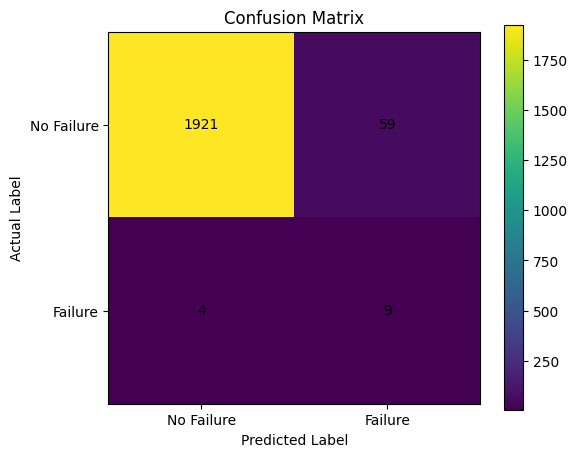

In [ ]:
# Step 24: Visualize the Confusion Matrix

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["No Failure", "Failure"])
plt.yticks([0, 1], ["No Failure", "Failure"])

# Add numbers inside the boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center")

plt.colorbar()
plt.show()

In [ ]:
# Step 25: Calculate feature importance

feature_importance = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
})

# Sort from most important to least important
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=True
)

print(importance_df)

                     Feature  Importance
4  Vibration_Rolling_Std_12h    0.053188
2           Sensor Voltage V    0.084567
0              Sensor Temp C    0.152714
1        Sensor Vibration mm    0.164980
3      Temp_Rolling_Mean_12h    0.544551


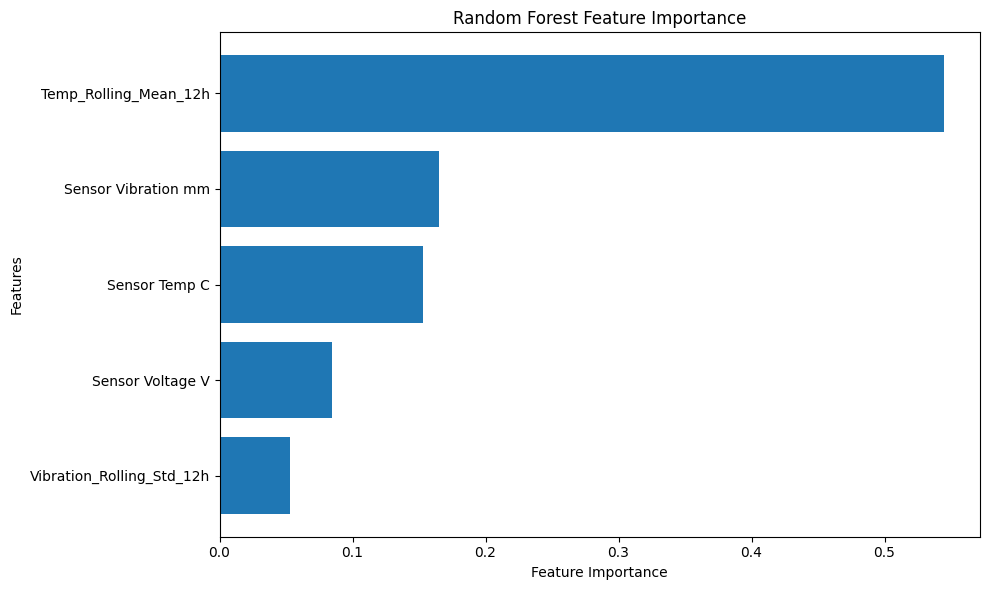

In [ ]:
# Step 26: Feature Importance Chart

plt.figure(figsize=(10, 6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [ ]:
# Step 27: Final model evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final, zero_division=0)
final_recall = recall_score(y_test, y_pred_final, zero_division=0)

print("FINAL MODEL PERFORMANCE")
print("-----------------------")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_final,
        target_names=["No Failure", "Failure"],
        zero_division=0
    )
)

FINAL MODEL PERFORMANCE
-----------------------
Accuracy : 0.9684
Precision: 0.1324
Recall   : 0.6923

Classification Report:
              precision    recall  f1-score   support

  No Failure       1.00      0.97      0.98      1980
     Failure       0.13      0.69      0.22        13

    accuracy                           0.97      1993
   macro avg       0.57      0.83      0.60      1993
weighted avg       0.99      0.97      0.98      1993



Business Recommendation

The predictive maintenance model should be used as an early-warning system for identifying machines that may experience catastrophic failure within the next 24 hours. In this model, the 12-hour rolling mean of temperature was the most important predictive feature, with an importance of approximately 0.545. Maintenance personnel should therefore pay particular attention to sustained temperature increases when reviewing machine health. Because the model uses a low decision threshold to prioritize failure detection, it generates some false alarms. Therefore, model alerts should be combined with sensor inspection and maintenance-team verification before replacing components. This recommendation is based on the synthetic dataset created for this project and should be validated with real operational data before deployment.

Conclusion

This project developed a predictive maintenance workflow for identifying potential catastrophic machine failures 24 hours in advance. The process included time-series feature engineering, 24-hour target shifting, chronological train-test splitting, Random Forest classification with balanced class weights, model evaluation, confusion-matrix analysis, and feature-importance visualization. In the synthetic dataset used for this project, the 12-hour rolling mean of temperature was the most important feature. The final model achieved a recall of 69.23% for failure cases using the selected 0.05 probability threshold. Since the dataset is synthetic, these results should be validated using real IoT sensor data before any operational deployment.